In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load your dataset (change file name if needed)
df = pd.read_csv("asteroid_close_approaches_2015_2035 (1).csv")

# show first 5 rows
df.head()

,designation,full_name,close_approach_date,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude,is_future
0,2022 AP1,(2022 AP1),2015-01-01 00:27,0.045100,6746806.0,17.55,0.013778,0.076571,11.891749,42810.0,11.886780,28.39,False
1,2015 AE45,(2015 AE45),2015-01-02 15:56,0.048239,7216474.0,18.77,0.048220,0.048258,7.065686,25436.0,7.057864,25.30,False
2,613286,613286 (2005 YQ96),2015-01-02 21:46,0.026522,3967664.0,10.32,0.026522,0.026522,12.703378,45732.0,12.695467,20.63,False
3,2014 YQ34,(2014 YQ34),2015-01-03 13:29,0.079692,11921722.0,31.01,0.078275,0.081108,24.982094,89936.0,24.980756,24.16,False
4,2014 YE42,(2014 YE42),2015-01-03 15:00,0.010995,1644896.0,4.28,0.010971,0.011020,13.998882,50396.0,13.981561,23.40,False


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
df.info()

Shape of dataset: (27430, 13)

Columns:
 Index(['designation', 'full_name', 'close_approach_date', 'distance_au',
       'dist_km', 'dist_lunar', 'distance_min_au', 'distance_max_au',
       'velocity_km_s', 'v_rel_kmh', 'velocity_infinity_km_s',
       'absolute_magnitude', 'is_future'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27430 entries, 0 to 27429
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   designation             27430 non-null  object 
 1   full_name               27430 non-null  object 
 2   close_approach_date     27430 non-null  object 
 3   distance_au             27430 non-null  float64
 4   dist_km                 27430 non-null  float64
 5   dist_lunar              27430 non-null  float64
 6   distance_min_au         27430 non-null  float64
 7   distance_max_au         27430 non-null  float64
 8   velocity_km_s           27430 non-nu

In [4]:
# remove duplicates
df = df.drop_duplicates()

# check missing values
print(df.isnull().sum())

# fill missing values (simple method)
df = df.fillna(method='ffill')

designation                0
full_name                  0
close_approach_date        0
distance_au                0
dist_km                    0
dist_lunar                 0
distance_min_au            0
distance_max_au            0
velocity_km_s              0
v_rel_kmh                  0
velocity_infinity_km_s    17
absolute_magnitude         8
is_future                  0
dtype: int64


C:\Users\mahee\AppData\Local\Temp\ipykernel_19416\2159833131.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [5]:
# convert date column (change name if needed)
df['close_approach_date'] = pd.to_datetime(df['close_approach_date'])

In [8]:
# ---------------- CHECK COLUMNS ----------------
print("Columns in dataset:\n", df.columns)

# ---------------- SAFE COLUMN DETECTION ----------------
distance_col = None
velocity_col = None

for col in df.columns:
    if "miss" in col.lower() or "distance" in col.lower():
        distance_col = col
    if "velocity" in col.lower() or "speed" in col.lower():
        velocity_col = col

# ---------------- ERROR HANDLING ----------------
if distance_col is None or velocity_col is None:
    print("❌ Column not found!")
    print("👉 Please check column names above and set manually like:")
    print("distance_col = 'your_column_name'")
    print("velocity_col = 'your_column_name'")
else:
    print("✅ Distance column:", distance_col)
    print("✅ Velocity column:", velocity_col)

    # ---------------- ANALYSIS ----------------
    closest = df.nsmallest(10, distance_col)
    print("\nTop 10 Closest Asteroids:\n", closest)

    fastest = df.nlargest(10, velocity_col)
    print("\nFastest Asteroids:\n", fastest)

    # ---------------- RISK ----------------
    def risk_label(row):
        if row[distance_col] < 5000000 and row[velocity_col] > 20000:
            return "Dangerous"
        else:
            return "Safe"

    df['Risk'] = df.apply(risk_label, axis=1)

    print("\nRisk column added successfully ✅")

Columns in dataset:
 Index(['designation', 'full_name', 'close_approach_date', 'distance_au',
       'dist_km', 'dist_lunar', 'distance_min_au', 'distance_max_au',
       'velocity_km_s', 'v_rel_kmh', 'velocity_infinity_km_s',
       'absolute_magnitude', 'is_future'],
      dtype='object')
✅ Distance column: distance_max_au
✅ Velocity column: velocity_infinity_km_s

Top 10 Closest Asteroids:
       designation           full_name close_approach_date  distance_au  \
22295   2025 UC11         (2025 UC11) 2025-10-30 12:11:00     0.000044   
9707     2020 VT4          (2020 VT4) 2020-11-13 17:21:00     0.000045   
21994     2025 TF           (2025 TF) 2025-10-01 00:49:00     0.000045   
19921     2024 XA           (2024 XA) 2024-12-01 09:46:00     0.000052   
18593    2024 LH1          (2024 LH1) 2024-06-06 14:02:00     0.000054   
19602    2024 UG9          (2024 UG9) 2024-10-30 12:42:00     0.000059   
9009      2020 QG           (2020 QG) 2020-08-16 04:09:00     0.000062   
11988    20

In [10]:
# ---------------- STEP 1: CHECK COLUMNS ----------------
print("Columns in your dataset:\n", df.columns)

# ---------------- STEP 2: SET CORRECT COLUMN NAMES ----------------
# ⚠️ CHANGE THESE AFTER YOU SEE YOUR COLUMN NAMES

distance_col = None
velocity_col = None

for col in df.columns:
    if "distance" in col.lower():
        distance_col = col
    if "velocity" in col.lower():
        velocity_col = col

print("Using distance column:", distance_col)
print("Using velocity column:", velocity_col)

# ---------------- STEP 3: CREATE RISK COLUMN ----------------

def risk_label(row):
    if row[distance_col] < 5000000 and row[velocity_col] > 20000:
        return "Dangerous"
    else:
        return "Safe"

df['Risk'] = df.apply(risk_label, axis=1)

print("✅ Risk column created successfully!")

# ---------------- STEP 4: TEST OUTPUT ----------------
df[[distance_col, velocity_col, 'Risk']].head()

Columns in your dataset:
 Index(['designation', 'full_name', 'close_approach_date', 'distance_au',
       'dist_km', 'dist_lunar', 'distance_min_au', 'distance_max_au',
       'velocity_km_s', 'v_rel_kmh', 'velocity_infinity_km_s',
       'absolute_magnitude', 'is_future', 'Risk'],
      dtype='object')
Using distance column: distance_max_au
Using velocity column: velocity_infinity_km_s
✅ Risk column created successfully!


,distance_max_au,velocity_infinity_km_s,Risk
0,0.076571,11.886780,Safe
1,0.048258,7.057864,Safe
2,0.026522,12.695467,Safe
3,0.081108,24.980756,Safe
4,0.011020,13.981561,Safe


Using: distance_max_au and velocity_infinity_km_s


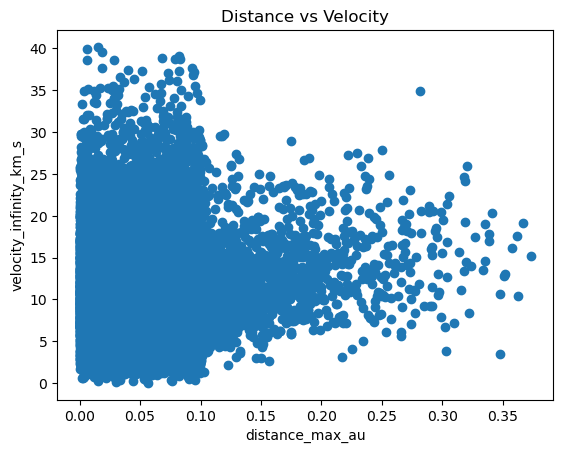

In [12]:
# ---------------- FIND CORRECT COLUMNS ----------------
distance_col = None
velocity_col = None

for col in df.columns:
    if "distance" in col.lower():
        distance_col = col
    if "velocity" in col.lower():
        velocity_col = col

print("Using:", distance_col, "and", velocity_col)

# ---------------- SCATTER PLOT ----------------
import matplotlib.pyplot as plt

plt.scatter(df[distance_col], df[velocity_col])
plt.xlabel(distance_col)
plt.ylabel(velocity_col)
plt.title("Distance vs Velocity")
plt.show()

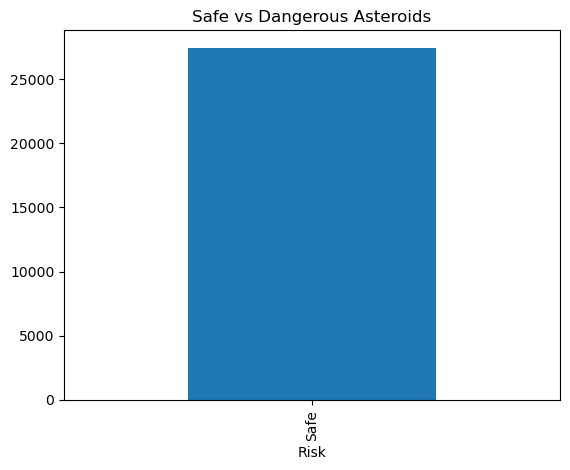

In [13]:
df['Risk'].value_counts().plot(kind='bar')
plt.title("Safe vs Dangerous Asteroids")
plt.show()

Using column: distance_max_au


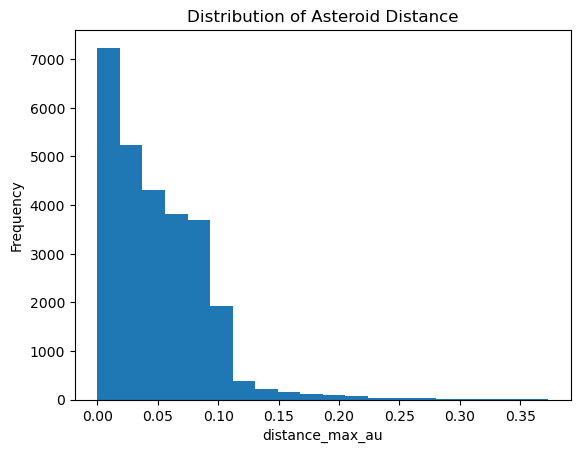

In [17]:

distance_col = None

for col in df.columns:
    if "distance" in col.lower():
        distance_col = col

print("Using column:", distance_col)

# ---------------- HISTOGRAM ----------------
import matplotlib.pyplot as plt

plt.hist(df[distance_col], bins=20)
plt.title("Distribution of Asteroid Distance")
plt.xlabel(distance_col)
plt.ylabel("Frequency")
plt.show()

In [19]:
# ---------------- FIND COLUMNS ----------------
distance_col = None
velocity_col = None

for col in df.columns:
    if "distance" in col.lower():
        distance_col = col
    if "velocity" in col.lower() or "speed" in col.lower():
        velocity_col = col

print("Distance column:", distance_col)
print("Velocity column:", velocity_col)

# ---------------- CREATE RISK ----------------
def risk_label(row):
    if row[distance_col] < 5000000 and row[velocity_col] > 20000:
        return "Dangerous"
    else:
        return "Safe"

df['Risk'] = df.apply(risk_label, axis=1)

# ---------------- MODEL ----------------
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = df[[distance_col, velocity_col]]   # ✅ FIXED
y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Distance column: distance_max_au
Velocity column: velocity_infinity_km_s
Accuracy: 1.0


In [1]:
pip install streamlit


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
